In [1]:
from pathlib import Path
import sys
import pandas as pd

PROJECT_ROOT = Path("~/UNSW-MRes/MRes/seacofs_eddy_dataset_modular").expanduser()

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from seacofs_eddy_dataset.config import load_config

CONFIG_PATH = PROJECT_ROOT / "config" / "local.yaml"
config = load_config(CONFIG_PATH)


In [7]:
files = sorted((config.output_root / "detections").glob("*.parquet"))

df_nenc = pd.concat(
    [pd.read_parquet(f) for f in files],
    ignore_index=True
)

df_nenc

,Day,nxc,nyc,Cyc,nic,njc,fnumber
0,1462,830.0,1515.0,AE,245,307,1461
1,1462,358.0,1408.0,AE,136,285,1461
2,1462,928.0,1356.0,CE,261,274,1461
3,1462,506.0,1354.0,CE,179,274,1461
4,1462,754.0,1285.0,AE,231,260,1461
...,...,...,...,...,...,...,...
414944,10650,349.0,158.0,AE,133,32,10641
414945,10650,973.0,126.0,CE,268,26,10641
414946,10650,805.0,95.0,AE,240,19,10641
414947,10650,157.0,34.0,CE,57,7,10641


In [10]:
# import numpy as np
# z_r = np.load('/srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset_modular/z_r.npy')

In [2]:
files = sorted((config.output_root / "surface_eddies").glob("*.parquet"))

df_doppio = pd.concat(
    [pd.read_parquet(f) for f in files],
    ignore_index=True
)

df_doppio

,Day,fnumber,nxc,nyc,nCyc,nic,njc,xc,yc,w,q11,q12,q22,Omega0,Omega,Rc,psi0,R
0,1462,1461,830.0,1515.0,AE,245,307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1462,1461,358.0,1408.0,AE,136,285,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1462,1461,928.0,1356.0,CE,261,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1462,1461,506.0,1354.0,CE,179,274,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1462,1461,754.0,1285.0,AE,231,260,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414944,10650,10641,349.0,158.0,AE,133,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
414945,10650,10641,973.0,126.0,CE,268,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
414946,10650,10641,805.0,95.0,AE,240,19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
414947,10650,10641,157.0,34.0,CE,57,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
files = sorted((config.output_root / "tracked").glob("*.parquet"))

df_tracked = pd.concat(
    [pd.read_parquet(f) for f in files],
    ignore_index=True
)

df_tracked

,Day,fnumber,nxc,nyc,nCyc,nic,njc,xc,yc,w,...,Omega,Rc,psi0,R,err,Omega0_abs,Cyc,eddy_idx,Eddy,next_num
0,1462,1461,312.0,293.0,CE,119,59,311.739045,292.852057,-0.000056,...,-0.000024,68.900202,57.520765,29.840039,0.299974,0.000024,CE,0,1,12788
1,1463,1461,356.0,180.0,AE,136,37,356.354073,179.836500,0.000040,...,0.000020,57.552631,-32.354674,41.316588,0.390000,0.000020,AE,0,2,12788
2,1463,1461,319.0,284.0,CE,122,58,319.170635,284.135356,-0.000052,...,-0.000030,49.274420,36.200521,32.894785,0.217802,0.000024,CE,1,1,12788
3,1463,1461,491.0,715.0,CE,175,145,490.366153,715.105353,-0.000054,...,-0.000023,79.980873,73.450302,47.860484,0.642543,0.000025,CE,2,3,12788
4,1464,1461,348.0,173.0,AE,133,35,348.312905,173.055772,0.000034,...,0.000019,56.900944,-30.111294,41.921099,0.317837,0.000016,AE,0,2,12788
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28877,10648,10641,229.0,757.0,AE,86,153,230.916049,761.869101,0.000058,...,0.000021,21.335619,-4.689110,11.292919,5.232532,0.000021,AE,1,12784,12788
28878,10649,10641,610.0,128.0,AE,203,26,610.203950,128.351822,0.000008,...,0.000002,86.582820,-8.392057,35.805516,0.406663,0.000004,AE,0,12780,12788
28879,10649,10641,195.0,495.0,AE,72,100,195.221726,495.253684,0.000045,...,0.000023,22.026775,-5.579971,16.237559,0.336925,0.000022,AE,1,12785,12788
28880,10650,10641,860.0,180.0,CE,250,37,859.994476,179.913208,-0.000008,...,-0.000003,108.796962,18.457635,62.024070,0.086968,0.000003,CE,0,12786,12788


In [4]:
df_processed = pd.read_parquet(
    config.output_root / "processed" / "eddy_dataset_processed.parquet"
)

df_processed

,Eddy,Day,Cyc,lon,lat,ic,jc,xc,yc,w,...,q11,q12,q22,Rc,psi0,AR,R,Age,Date,fname
0,1,1465,CE,152.719389,-38.902070,171,25,475.960098,123.953440,-0.000019,...,1.064809,-0.157818,1.059543,31.929701,7.971426,1.161496,18.674495,23,1994-01-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
1,1,1466,CE,152.682854,-38.912497,171,25,473.270784,121.774679,-0.000026,...,1.064812,-0.118086,1.040489,31.929701,7.971426,1.119917,20.716544,23,1994-01-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
2,1,1467,CE,152.646305,-38.922923,170,24,470.581471,119.595919,-0.000033,...,1.064814,-0.078354,1.021435,31.929701,7.971426,1.081228,22.758594,23,1994-01-07,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
3,1,1468,CE,152.666617,-38.895161,170,25,471.369402,123.110378,-0.000025,...,0.981636,0.002526,1.061739,31.945180,7.711901,1.040082,19.784771,23,1994-01-08,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
4,1,1469,CE,152.733361,-38.791293,171,28,473.557553,135.987188,-0.000029,...,1.234982,-0.126441,0.984268,31.960659,7.452376,1.175694,19.203373,23,1994-01-09,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1800,66,10626,AE,153.999190,-33.579927,153,146,409.779203,720.460444,0.000030,...,1.326127,-0.087612,0.767327,124.193583,-85.122986,1.332961,69.977512,26,2019-02-04,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
1801,66,10627,AE,153.966983,-33.589999,152,146,407.282381,718.387159,0.000027,...,1.342632,-0.114421,0.760611,122.935408,-85.244892,1.358807,79.480139,26,2019-02-05,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
1802,66,10628,AE,153.934768,-33.600072,151,145,404.785558,716.313874,0.000024,...,1.359137,-0.141229,0.753894,121.677233,-85.366799,1.387214,88.982766,26,2019-02-06,/srv/scratch/z3533156/26year_BRAN2020/outer_av...
1803,66,10629,AE,153.890558,-33.622697,150,144,401.658839,712.549527,0.000022,...,1.511207,-0.165680,0.684915,141.463782,-101.406368,1.537360,93.758093,26,2019-02-07,/srv/scratch/z3533156/26year_BRAN2020/outer_av...


In [5]:
df_processed.Age.max()

np.int64(48)

(array([232., 140., 346., 237., 438., 244.,  45.,  25.,  47.,  51.]),
 array([  59.05078564,  196.48466544,  333.91854524,  471.35242504,
         608.78630484,  746.22018464,  883.65406444, 1021.08794424,
        1158.52182404, 1295.95570384, 1433.38958364]),
 <BarContainer object of 10 artists>)

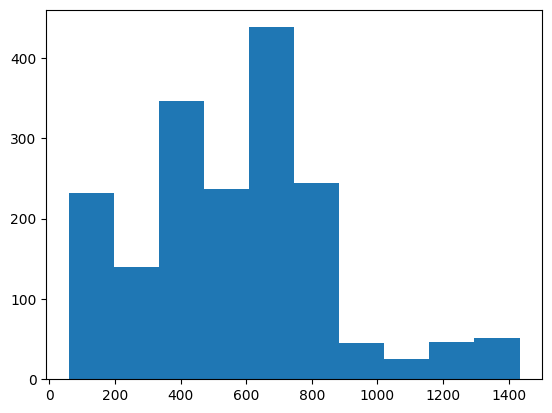

In [6]:
import matplotlib.pyplot as plt
plt.hist(df_processed.yc)